In [26]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from pathlib import Path
import pandas as pd

data_dir = Path("../../data")
X_train = pd.read_csv(data_dir / "X_train.csv")
X_test = pd.read_csv(data_dir / "X_test.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").values.ravel()
y_test = pd.read_csv(data_dir / "y_test.csv").values.ravel()

print("Loaded:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Loaded:
X_train: (227972, 33)
X_test:  (10852, 33)
y_train: (227972,)
y_test:  (10852,)


In [28]:
from src.predictors.predictors import EnsembleLearner
from src.evaluation.evaluate_classifier import evaluate_classifier, print_classifier_results


def print_evaluation(sub_model, X_train, X_test, y_train, y_test):
    sub_model_eval = clone(sub_model)
    sub_model_eval.fit(X_train, y_train)
    results = evaluate_classifier(
        sub_model_eval,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    print_classifier_results(results)

model = EnsembleLearner(meta_test_size=0.15)
print("Initializing model...")

Initializing model...


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# Add Logistic Regression (Add scaling and L2 regularization)
logistic_regression = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    l1_ratio=0,
    max_iter=10000
)
print_evaluation(logistic_regression, X_train, X_test, y_train, y_test)
model.add_learner("Logistic Regression (L2)", logistic_regression)

c:\Users\523ba\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 71.94%
Test accuracy   : 71.14%

Train log loss  : 0.5400
Test log loss   : 0.5512

Train ROC-AUC   : 0.7998
Test ROC-AUC    : 0.7876

Train confusion matrix:
[[81998 31988]
 [31988 81998]]

Test confusion matrix:
[[3860 1566]
 [1566 3860]]


In [30]:
from lightgbm import LGBMClassifier

# Add LightGBM (The dominant algorithm for Men's data)
lightgbm = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1,
)
print_evaluation(lightgbm, X_train, X_test, y_train, y_test)
model.add_learner("LightGBM", lightgbm)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 72.75%
Test accuracy   : 71.04%

Train log loss  : 0.5278
Test log loss   : 0.5476

Train ROC-AUC   : 0.8097
Test ROC-AUC    : 0.7900

Train confusion matrix:
[[82923 31063]
 [31050 82936]]

Test confusion matrix:
[[3853 1573]
 [1570 3856]]


In [31]:
from xgboost import XGBClassifier

# Add XGBoost (Constrain depth to prevent memorization)
xgboost = XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
)
print_evaluation(xgboost, X_train, X_test, y_train, y_test)
model.add_learner("XGBoost", xgboost)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 73.09%
Test accuracy   : 71.18%

Train log loss  : 0.5231
Test log loss   : 0.5473

Train ROC-AUC   : 0.8139
Test ROC-AUC    : 0.7904

Train confusion matrix:
[[83302 30684]
 [30653 83333]]

Test confusion matrix:
[[3863 1563]
 [1565 3861]]


In [32]:
from sklearn.ensemble import RandomForestClassifier

# Add Random Forest
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)
print_evaluation(random_forest, X_train, X_test, y_train, y_test)
model.add_learner("Random Forest", random_forest)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 75.53%
Test accuracy   : 70.80%

Train log loss  : 0.4958
Test log loss   : 0.5483

Train ROC-AUC   : 0.8443
Test ROC-AUC    : 0.7890

Train confusion matrix:
[[86024 27962]
 [27812 86174]]

Test confusion matrix:
[[3843 1583]
 [1586 3840]]


In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add KNN classifier
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=35,
        weights="distance",
        metric="minkowski",
        p=2,
    ))
])
print_evaluation(knn, X_train, X_test, y_train, y_test)
model.add_learner("KNN Classifier", knn)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 100.00%
Test accuracy   : 69.44%

Train log loss  : 0.0000
Test log loss   : 0.6004

Train ROC-AUC   : 1.0000
Test ROC-AUC    : 0.7750

Train confusion matrix:
[[113986      0]
 [     0 113986]]

Test confusion matrix:
[[3768 1658]
 [1658 3768]]


In [34]:
from sklearn.neural_network import MLPClassifier

# Add Basic Neural Network
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=42,
    ))
])
print_evaluation(mlp, X_train, X_test, y_train, y_test)
model.add_learner("Basic Neural Network", mlp)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 72.32%
Test accuracy   : 70.98%

Train log loss  : 0.5346
Test log loss   : 0.5472

Train ROC-AUC   : 0.8042
Test ROC-AUC    : 0.7898

Train confusion matrix:
[[83408 30578]
 [32534 81452]]

Test confusion matrix:
[[3901 1525]
 [1624 3802]]


Partitioning data to prevent leakage...
Training base learners...


c:\Users\523ba\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Logistic Regression (L2) train=0.7198  test=0.7167
LightGBM             train=0.7284  test=0.7199
XGBoost              train=0.7322  test=0.7188
Random Forest        train=0.7593  test=0.7178
KNN Classifier       train=1.0000  test=0.7048
Basic Neural Network train=0.7245  test=0.7191
Generating meta-features...
Training meta-learner...
Matrix 	ilde{E}^T * 	ilde{E} (Error Correlation):
[[1.     0.879  0.8805 0.8276 0.2557 0.8789]
 [0.879  1.     0.958  0.8775 0.2565 0.8835]
 [0.8805 0.958  1.     0.8848 0.2611 0.8879]
 [0.8276 0.8775 0.8848 1.     0.281  0.8302]
 [0.2557 0.2565 0.2611 0.281  1.     0.2524]
 [0.8789 0.8835 0.8879 0.8302 0.2524 1.    ]]


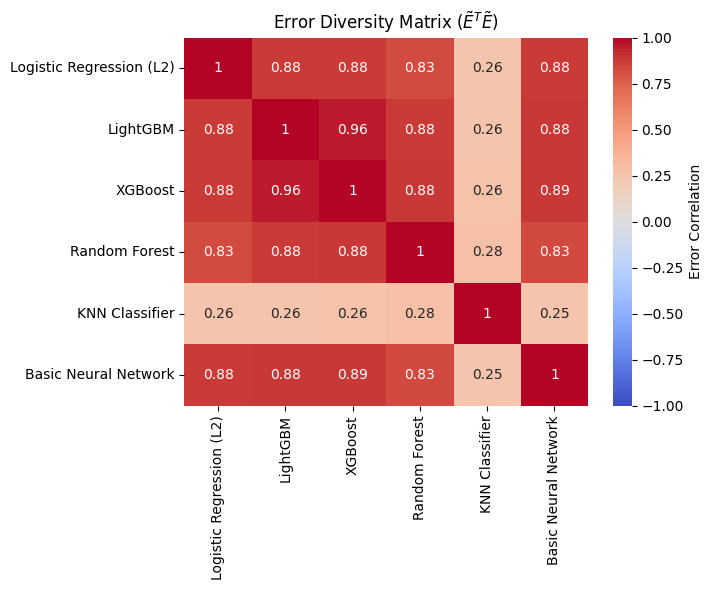

In [35]:
# Train the architecture
model.fit(X_train, y_train)
model.plot_error_heatmap(X_train, y_train)

In [36]:
# Where did we end up
results = evaluate_classifier(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
)
print_classifier_results(results)

Classifier Evaluation
Train games     : 227,972
Test games      : 10,852

Train accuracy  : 69.07%
Test accuracy   : 71.12%

Train log loss  : 0.5887
Test log loss   : 0.5530

Train ROC-AUC   : 0.7599
Test ROC-AUC    : 0.7909

Train confusion matrix:
[[78655 35331]
 [35191 78795]]

Test confusion matrix:
[[3848 1578]
 [1556 3870]]
